In [ ]:
import pandas as pd
# Đọc tệp CSV thành một bảng. Tên df là viết tắt quen dùng của data frame.
df = pd.read_csv("/content/gia_nha.csv")
print("Kich thuoc bang (so dong, so cot):", df.shape)
print()
print("Nam dong dau tien:")
print(df.head())
print()
print("Ten cac cot:", list(df.columns))
print()
print("Thong ke nhanh cot dien_tich va cot gia:")
print(df[["dien_tich", "gia"]].describe().round(2))
print()
print("So o bi thieu trong tung cot:")
print(df.isna().sum())

Kich thuoc bang (so dong, so cot): (60, 4)

Nam dong dau tien:
   dien_tich  so_phong  tuoi_nha   gia
0       35.5         1        18  3.00
1       37.6         2         7  3.87
2       49.4         2        20  4.25
3       49.0         2        16  4.60
4       49.9         1        12  3.99

Ten cac cot: ['dien_tich', 'so_phong', 'tuoi_nha', 'gia']

Thong ke nhanh cot dien_tich va cot gia:
       dien_tich    gia
count      60.00  60.00
mean       77.73   6.49
std        20.22   1.64
min        35.50   3.00
25%        63.02   5.16
50%        75.10   6.40
75%        91.88   7.70
max       117.50   9.74

So o bi thieu trong tung cot:
dien_tich    0
so_phong     0
tuoi_nha     0
gia          0
dtype: int64


In [ ]:
#‐*‐ coding: utf‐8‐
import pandas as pd

df = pd.read_csv("/content/gia_nha.csv")

# Lấy 5 căn trải đều từ nhỏ nhất tới lớn nhất, không lấy 5 căn đầu bảng
# vì chúng có diện tích gần bằng nhau nên nhìn không rõ.
nho = df.iloc[[0, 14, 29, 44, 59]]
x = nho["dien_tich"].to_numpy()
y = nho["gia"].to_numpy()


def mse(w, b):
    """Sai số trung bình bình phương của đường thẳng y = w*x + b."""
    y_du_doan = w * x + b
    sai_so = y - y_du_doan
    return (sai_so ** 2).mean()


print("Nam can duoc chon:")

for i in range(5):
    print(f" {x[i]:6.1f} m2‐> {y[i]:5.2f} ty")

print()

for w, b in [(0.05, 1.5), (0.08, 0.5)]:
    print(f"Duong thang y = {w} * x + {b}")

    for i in range(5):
        du_doan = w * x[i] + b
        sai_so = y[i] - du_doan

        print()
        print(
            f" x = {x[i]:6.1f} that = {y[i]:5.2f}"
            f" du doan = {du_doan:5.2f} sai so = {sai_so:+6.2f}"
        )

    print(f" MSE = {mse(w, b):.4f}")

print("Duong nao co MSE nho hon thi duong do khop du lieu tot hon.")

Nam can duoc chon:
   35.5 m2‐>  3.00 ty
   61.3 m2‐>  4.56 ty
   74.2 m2‐>  7.17 ty
   91.3 m2‐>  7.83 ty
  115.9 m2‐>  9.01 ty

Duong thang y = 0.05 * x + 1.5

 x =   35.5 that =  3.00 du doan =  3.28 sai so =  -0.28

 x =   61.3 that =  4.56 du doan =  4.56 sai so =  -0.00

 x =   74.2 that =  7.17 du doan =  5.21 sai so =  +1.96

 x =   91.3 that =  7.83 du doan =  6.07 sai so =  +1.76

 x =  115.9 that =  9.01 du doan =  7.30 sai so =  +1.71
 MSE = 1.9947
Duong thang y = 0.08 * x + 0.5

 x =   35.5 that =  3.00 du doan =  3.34 sai so =  -0.34

 x =   61.3 that =  4.56 du doan =  5.40 sai so =  -0.84

 x =   74.2 that =  7.17 du doan =  6.44 sai so =  +0.73

 x =   91.3 that =  7.83 du doan =  7.80 sai so =  +0.03

 x =  115.9 that =  9.01 du doan =  9.77 sai so =  -0.76
 MSE = 0.3896
Duong nao co MSE nho hon thi duong do khop du lieu tot hon.


In [ ]:
# -*- coding: utf-8 -*-
"""Bước 3: tìm w và b tốt nhất bằng công thức, không cần thư viện"""

import numpy as np
import pandas as pd

df = pd.read_csv("/content/gia_nha.csv")
x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

# Công thức bình phương tối thiểu cho đường thẳng một biến
tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

print(f"Trung bình dien tich : {x_tb:.4f}")
print(f"Trung bình gia       : {y_tb:.4f}")
print(f"Tu so                : {tu_so:.4f}")
print(f"Mau so               : {mau_so:.4f}")
print()

print(f"He so goc    w = {w:.6f}")
print(f"He so chan   b = {b:.6f}")
print()

print(f"Mo hinh: gia = {w:.4f} * dien_tich + ({b:.4f})")
print()

y_du_doan = w * x + b
mse = ((y - y_du_doan) ** 2).mean()
print(f"MSE tren toan bo 60 can: {mse:.4f}")

# Dự đoán cho một căn 80 m2
print(f"Can 80 m2 duoc du doan: {w * 80 + b:.3f} ty dong")

Trung bình dien tich : 77.7317
Trung bình gia       : 6.4933
Tu so                : 1890.2297
Mau so               : 24120.2898

He so goc    w = 0.078367
He so chan   b = 0.401752

Mo hinh: gia = 0.0784 * dien_tich + (0.4018)

MSE tren toan bo 60 can: 0.1790
Can 80 m2 duoc du doan: 6.671 ty dong


In [ ]:
# -*- coding: utf-8 -*-
"""Bước 4: làm lại đúng việc đó bằng scikit-learn, chỉ mất ba dòng."""

import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("/content/gia_nha.csv")

# X phải là bảng hai chiều, y là dãy một chiều.
# Chú ý X viết hai cặp ngoặc vuông, còn y chỉ một cặp.
X = df[["dien_tich"]]
y = df["gia"]

mo_hinh = LinearRegression()
mo_hinh.fit(X, y)

print("He so goc w =", round(float(mo_hinh.coef_[0]), 6))
print("He so chan b =", round(float(mo_hinh.intercept_), 6))
print()

# So sánh với kết quả tính tay ở bước 3
print("Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752")
print()

can_moi = pd.DataFrame({"dien_tich": [80.0, 100.0]})
du_doan = mo_hinh.predict(can_moi)

for dt, gia in zip(can_moi["dien_tich"], du_doan):
    print(f"Can {dt:.0f} m2 -> du doan {gia:.3f} ty dong")

He so goc w = 0.078367
He so chan b = 0.401752

Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752

Can 80 m2 -> du doan 6.671 ty dong
Can 100 m2 -> du doan 8.238 ty dong


In [ ]:
# -*- coding: utf-8 -*-
"""Bước 5: chia dữ liệu và chấm điểm mô hình bằng các độ đo chuẩn."""

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/gia_nha.csv")

X = df[["dien_tich"]]
y = df["gia"]

# 80 phần trăm để học, 20 phần trăm để kiểm tra.
# random_state cố định để lần nào chia cũng ra đúng một cách chia.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("So can de hoc       :", len(X_train))
print("So can de kiem tra  :", len(X_test))
print()

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)  # chỉ học trên tập học

y_pred = mo_hinh.predict(X_test)  # chấm điểm trên tập kiểm tra

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE = {mae:.4f} ty dong")
print(f"MSE = {mse:.4f}")
print()
print(f"RMSE = {rmse:.4f} ty dong")
print(f"R2 = {r2:.4f}")

print("Mot vai can trong tap kiem tra:")

for dt, that, du_doan in list(
    zip(X_test["dien_tich"], y_test, y_pred)
)[:5]:
    print(
        f" {dt:6.1f} m2 that = {that:5.2f} "
        f"du doan = {du_doan:5.2f}"
        f" sai so = {that - du_doan:+5.2f}"
    )

So can de hoc       : 48
So can de kiem tra  : 12

MAE = 0.2578 ty dong
MSE = 0.1392

RMSE = 0.3730 ty dong
R2 = 0.9622
Mot vai can trong tap kiem tra:
   35.5 m2 that =  3.00 du doan =  3.22 sai so = -0.22
   50.4 m2 that =  4.24 du doan =  4.38 sai so = -0.14
   82.5 m2 that =  7.28 du doan =  6.88 sai so = +0.40
   93.6 m2 that =  7.63 du doan =  7.74 sai so = -0.11
   59.6 m2 that =  5.14 du doan =  5.09 sai so = +0.05


In [ ]:
# -*- coding: utf-8 -*-
"""Bước 6: tự đi tìm w và b bằng cách dò từng bước nhỏ.

Đây là cách máy học khi bài toán không có công thức đóng. Với hồi quy tuyến
tính ta đã có công thức rồi, nên đoạn này chỉ để thấy cơ chế hoạt động.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("/content/gia_nha.csv")

x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Đưa diện tích về thang đo nhỏ quanh số 0. Thiếu bước này thuật toán sẽ vỡ.
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

w, b = 0.0, 0.0  # bắt đầu từ một đường thẳng nằm ngang đi qua gốc
toc_do_hoc = 0.1  # mỗi vòng lặp đi một bước dài bằng 0.1 lần độ dốc
so_vong = 200
n = len(x)

print("Vong w b MSE")

for vong in range(1, so_vong + 1):
    y_du_doan = w * x + b

    # Chú ý: đây là dự đoán trừ giá thật, tức sai số của Mục 4 đảo dấu.
    # Hai công thức độ dốc bên dưới viết theo đúng chiều này, đừng đổi dấu.
    chenh_lech = y_du_doan - y

    # Độ dốc của MSE theo w và theo b
    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()

    # Đi ngược hướng dốc thì sai số giảm
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

    if vong in (1, 2, 5, 10, 25, 50, 100, 200):
        # Tính lại MSE bằng w và b VỪA cập nhật
        mse = (((w * x + b) - y) ** 2).mean()
        print(f"{vong:4d} {w:7.4f} {b:7.4f} {mse:8.4f}")

print()

# Đổi w và b về lại thang đo mét vuông ban đầu
w_goc = w / x_do_lech
b_goc = b - w * x_tb / x_do_lech

print("Sau khi doi ve thang do met vuong:")
print(f" w = {w_goc:.6f}")
print(f" b = {b_goc:.6f}")

print("So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752")


Vong w b MSE
   1  0.3143  1.2987  28.7437
   2  0.5657  2.3376  18.4604
   5  1.0564  4.3656   4.9714
  10  1.4025  5.7961   0.6936
  25  1.5653  6.4688   0.1797
  50  1.5712  6.4932   0.1790
 100  1.5713  6.4933   0.1790
 200  1.5713  6.4933   0.1790

Sau khi doi ve thang do met vuong:
 w = 0.078367
 b = 0.401752
So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752


In [ ]:
# -*- coding: utf-8 -*-
"""Bước 7: dùng thêm số phòng và tuổi nhà, xem mô hình có khá hơn không."""

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/gia_nha.csv")
y = df["gia"]

# Chỉ đổi đúng một chỗ: danh sách cột đưa vào X
X_mot = df[["dien_tich"]]
X_ba = df[["dien_tich", "so_phong", "tuoi_nha"]]

for ten, X in [("Mot bien ", X_mot), ("Ba bien ", X_ba)]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    mo_hinh = LinearRegression()
    mo_hinh.fit(X_train, y_train)

    r2 = r2_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: R2 tren tap kiem tra = {r2:.4f}")

print()

# Xem kỹ các hệ số của mô hình ba biến
X_train, X_test, y_train, y_test = train_test_split(
    X_ba, y, test_size=0.2, random_state=42
)

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

print("He so cua tung bien:")

for ten_cot, he_so in zip(X_ba.columns, mo_hinh.coef_):
    print(f" {ten_cot:12s} {he_so:+.4f}")

print(f" {'he so chan':12s} {mo_hinh.intercept_:+.4f}")


Mot bien : R2 tren tap kiem tra = 0.9622
Ba bien : R2 tren tap kiem tra = 0.9761

He so cua tung bien:
 dien_tich    +0.0701
 so_phong     +0.3042
 tuoi_nha     -0.0295
 he so chan   +0.6917


BÀI TẬP 1

In [ ]:
# -*- coding: utf-8 -*-

import pandas as pd

df = pd.read_csv("/content/gia_nha.csv")

nhom_lon = df[df["dien_tich"] > 100]

so_can = len(nhom_lon)
gia_trung_binh = nhom_lon["gia"].mean()

print("So can co dien tich > 100 m2:", so_can)
print(f"Gia trung binh: {gia_trung_binh:.3f} ty dong")

So can co dien tich > 100 m2: 10
Gia trung binh: 8.962 ty dong


BÀI TẬP 2

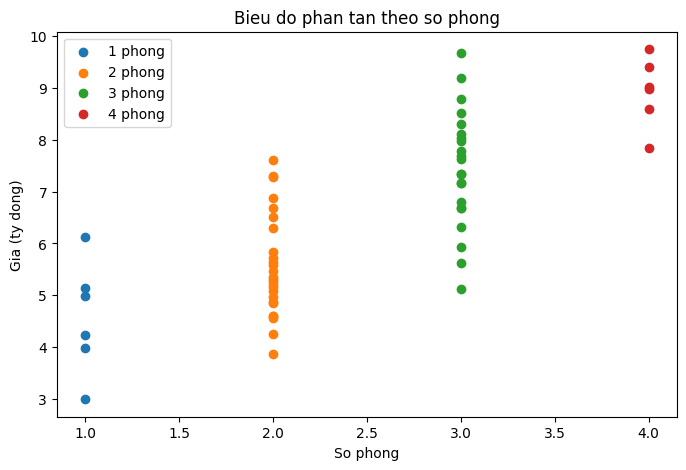

Nhan xet: Gia can ho co xu huong tang khi so phong tang,
tuy nhien cac diem du lieu van co su phan tan.


In [ ]:
# -*- coding: utf-8 -*-

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/gia_nha.csv")

plt.figure(figsize=(8, 5))

for so_phong in sorted(df["so_phong"].unique()):
    nhom = df[df["so_phong"] == so_phong]
    plt.scatter(
        nhom["so_phong"],
        nhom["gia"],
        label=f"{so_phong} phong"
    )

plt.xlabel("So phong")
plt.ylabel("Gia (ty dong)")
plt.title("Bieu do phan tan theo so phong")
plt.legend()

plt.savefig("bai2.png", dpi=150)
plt.show()

print("Nhan xet: Gia can ho co xu huong tang khi so phong tang,")
print("tuy nhien cac diem du lieu van co su phan tan.")

BÀI TẬP 3

In [ ]:
# -*- coding: utf-8 -*-

import pandas as pd

df = pd.read_csv("/content/gia_nha.csv")

x = df["tuoi_nha"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

print(f"He so goc w = {w:.6f}")
print(f"He so chan b = {b:.6f}")

print()
print("Nhan xet:")
print("w mang dau am, cho thay khi tuoi nha tang thi gia du doan")
print("co xu huong giam.")
print("Cu the, w cho biet gia thay doi trung binh bao nhieu ty dong")
print("khi tuoi nha tang them 1 nam.")

He so goc w = -0.037858
He so chan b = 6.983593

Nhan xet:
w mang dau am, cho thay khi tuoi nha tang thi gia du doan
co xu huong giam.
Cu the, w cho biet gia thay doi trung binh bao nhieu ty dong
khi tuoi nha tang them 1 nam.


BÀI TẬP 4

In [ ]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd

df = pd.read_csv("/content/gia_nha.csv")

x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x_goc.mean()
x_do_lech = x_goc.std()

x = (x_goc - x_tb) / x_do_lech

so_vong = 200
n = len(x)


def chay_gradient_descent(toc_do_hoc):
    w = 0.0
    b = 0.0

    for vong in range(1, so_vong + 1):
        y_du_doan = w * x + b
        chenh_lech = y_du_doan - y

        grad_w = (2 / n) * (chenh_lech * x).sum()
        grad_b = (2 / n) * chenh_lech.sum()

        w -= toc_do_hoc * grad_w
        b -= toc_do_hoc * grad_b

    mse = (((w * x + b) - y) ** 2).mean()

    return mse


mse_001 = chay_gradient_descent(0.001)
mse_102 = chay_gradient_descent(1.02)

print(f"MSE voi toc do hoc 0.001: {mse_001:.4f}")
print(f"MSE voi toc do hoc 1.02 : {mse_102:.4f}")

print()
print("Nhan xet:")
print("Toc do hoc 0.001 qua nho nen moi buoc cap nhat rat ngan,")
print("sau 200 vong van chua tien gan den diem toi uu.")

print()
print("Toc do hoc 1.02 qua lon nen mo hinh nhay qua diem toi uu,")
print("lam MSE tang rat nhanh thay vi giam.")

MSE voi toc do hoc 0.001: 20.2175
MSE voi toc do hoc 1.02 : 290391782.0192

Nhan xet:
Toc do hoc 0.001 qua nho nen moi buoc cap nhat rat ngan,
sau 200 vong van chua tien gan den diem toi uu.

Toc do hoc 1.02 qua lon nen mo hinh nhay qua diem toi uu,
lam MSE tang rat nhanh thay vi giam.


BÀI TẬP 5

In [ ]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd

df = pd.read_csv("/content/gia_nha.csv")

x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x_goc.mean()
x_do_lech = x_goc.std()

x = (x_goc - x_tb) / x_do_lech

so_vong = 200
n = len(x)


def chay_gradient_descent(toc_do_hoc):
    w = 0.0
    b = 0.0

    for vong in range(1, so_vong + 1):
        y_du_doan = w * x + b
        chenh_lech = y_du_doan - y

        grad_w = (2 / n) * (chenh_lech * x).sum()
        grad_b = (2 / n) * chenh_lech.sum()

        w -= toc_do_hoc * grad_w
        b -= toc_do_hoc * grad_b

    mse = (((w * x + b) - y) ** 2).mean()

    return mse


mse_001 = chay_gradient_descent(0.001)
mse_102 = chay_gradient_descent(1.02)

print(f"MSE voi toc do hoc 0.001: {mse_001:.4f}")
print(f"MSE voi toc do hoc 1.02 : {mse_102:.4f}")

print()
print("Nhan xet:")
print("Toc do hoc 0.001 qua nho nen moi buoc cap nhat rat ngan,")
print("sau 200 vong van chua tien gan den diem toi uu.")

print()
print("Toc do hoc 1.02 qua lon nen mo hinh nhay qua diem toi uu,")
print("lam MSE tang rat nhanh thay vi giam.")

MSE voi toc do hoc 0.001: 20.2175
MSE voi toc do hoc 1.02 : 290391782.0192

Nhan xet:
Toc do hoc 0.001 qua nho nen moi buoc cap nhat rat ngan,
sau 200 vong van chua tien gan den diem toi uu.

Toc do hoc 1.02 qua lon nen mo hinh nhay qua diem toi uu,
lam MSE tang rat nhanh thay vi giam.


BÀI TẬP 6

In [ ]:
# -*- coding: utf-8 -*-

w = 0.078367
b = 0.401752


def du_doan_gia(dien_tich):
    if dien_tich < 35.5 or dien_tich > 117.5:
        print(
            f"Canh bao: dien tich {dien_tich} m2 "
            "nam ngoai khoang du lieu."
        )

    gia_du_doan = w * dien_tich + b

    return gia_du_doan


dien_tich_1 = 60
dien_tich_2 = 80
dien_tich_3 = 200

gia_1 = du_doan_gia(dien_tich_1)
gia_2 = du_doan_gia(dien_tich_2)
gia_3 = du_doan_gia(dien_tich_3)

print(f"Can {dien_tich_1} m2 -> {gia_1:.3f} ty dong")
print(f"Can {dien_tich_2} m2 -> {gia_2:.3f} ty dong")
print(f"Can {dien_tich_3} m2 -> {gia_3:.3f} ty dong")

Canh bao: dien tich 200 m2 nam ngoai khoang du lieu.
Can 60 m2 -> 5.104 ty dong
Can 80 m2 -> 6.671 ty dong
Can 200 m2 -> 16.075 ty dong


HÌNH 1

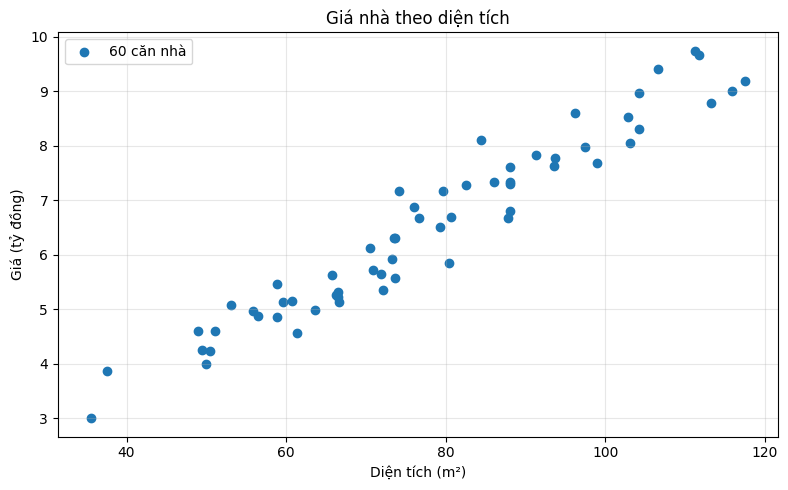

In [4]:
# -*- coding: utf-8 -*-

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/gia_nha.csv")

plt.figure(figsize=(8, 5))

plt.scatter(
    df["dien_tich"],
    df["gia"],
    label="60 căn nhà"
)

plt.xlabel("Diện tích (m²)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Giá nhà theo diện tích")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

HÌNH 2

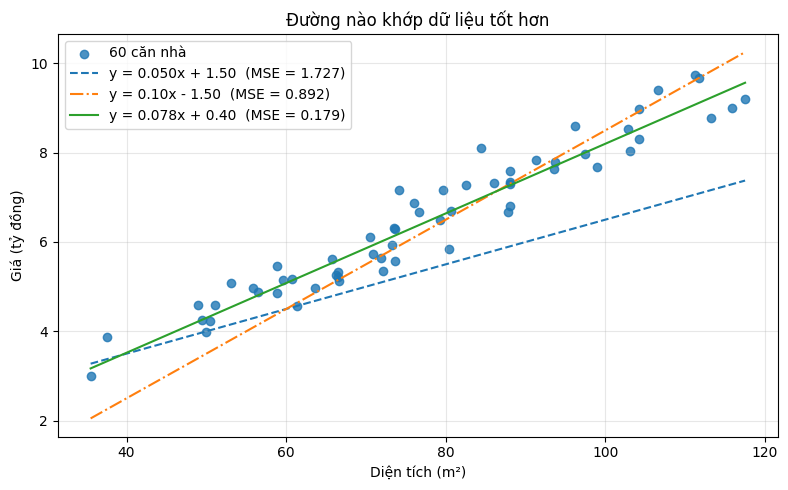

In [5]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/gia_nha.csv")

x = df["dien_tich"]
y = df["gia"]

# 3 đường thẳng
w1, b1 = 0.050, 1.50
w2, b2 = 0.10, -1.50
w3, b3 = 0.078, 0.40

# Tạo các giá trị x để vẽ đường
x_ve = np.linspace(x.min(), x.max(), 200)

y1 = w1 * x_ve + b1
y2 = w2 * x_ve + b2
y3 = w3 * x_ve + b3

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    y,
    label="60 căn nhà",
    alpha=0.8
)

plt.plot(
    x_ve,
    y1,
    linestyle="--",
    label="y = 0.050x + 1.50  (MSE = 1.727)"
)

plt.plot(
    x_ve,
    y2,
    linestyle="-.",
    label="y = 0.10x - 1.50  (MSE = 0.892)"
)

plt.plot(
    x_ve,
    y3,
    linestyle="-",
    label="y = 0.078x + 0.40  (MSE = 0.179)"
)

plt.xlabel("Diện tích (m²)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Đường nào khớp dữ liệu tốt hơn")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

HÌNH 3

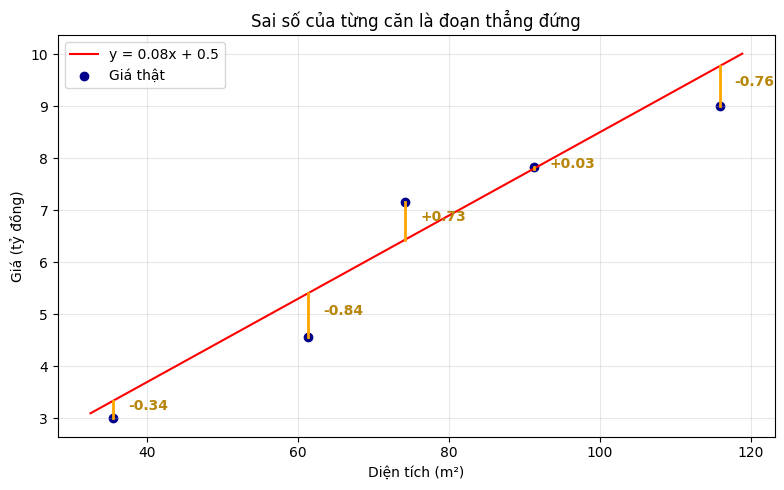

In [6]:
# -*- coding: utf-8 -*-

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/gia_nha.csv")

# Lấy 5 căn hộ để minh họa
df_5 = df.iloc[[0, 14, 29, 44, 59]]

x = df_5["dien_tich"]
y = df_5["gia"]

# Mô hình y = 0.08x + 0.5
w = 0.08
b = 0.5

y_du_doan = w * x + b

plt.figure(figsize=(8, 5))

# Đường hồi quy
x_ve = [x.min() - 3, x.max() + 3]
y_ve = [w * x_ve[0] + b, w * x_ve[1] + b]

plt.plot(
    x_ve,
    y_ve,
    color="red",
    label="y = 0.08x + 0.5"
)

# Các điểm giá thật
plt.scatter(
    x,
    y,
    color="darkblue",
    label="Giá thật"
)

# Vẽ đoạn sai số
for xi, yi, ypi in zip(x, y, y_du_doan):
    plt.plot(
        [xi, xi],
        [yi, ypi],
        color="orange",
        linewidth=2
    )

    sai_so = yi - ypi

    plt.text(
        xi + 2,
        (yi + ypi) / 2,
        f"{sai_so:+.2f}",
        color="darkgoldenrod",
        fontweight="bold"
    )

plt.xlabel("Diện tích (m²)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Sai số của từng căn là đoạn thẳng đứng")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

HÌNH 4

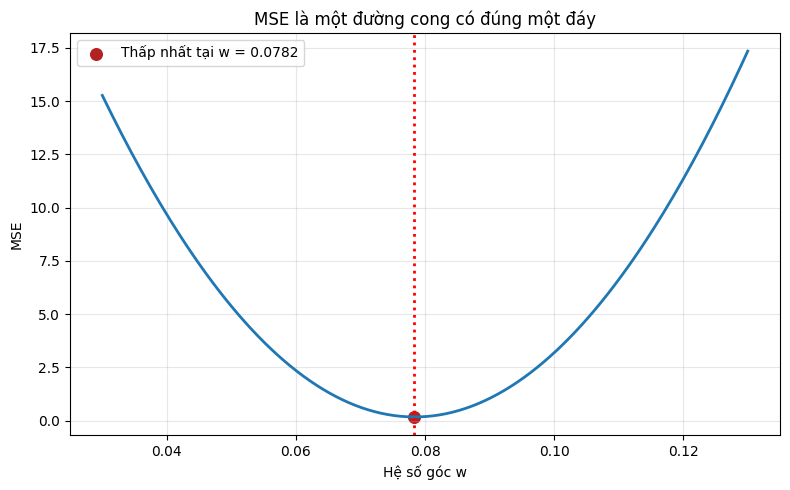

In [7]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/gia_nha.csv")

x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Giữ hệ số chặn b cố định
b = 0.4

# Tạo nhiều giá trị w
w_values = np.linspace(0.03, 0.13, 200)

mse_values = []

for w in w_values:
    y_du_doan = w * x + b
    mse = ((y - y_du_doan) ** 2).mean()
    mse_values.append(mse)

# Tìm w có MSE nhỏ nhất
vi_tri_min = np.argmin(mse_values)
w_tot_nhat = w_values[vi_tri_min]
mse_min = mse_values[vi_tri_min]

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))

plt.plot(
    w_values,
    mse_values,
    linewidth=2
)

# Điểm thấp nhất
plt.scatter(
    w_tot_nhat,
    mse_min,
    color="firebrick",
    s=70,
    label=f"Thấp nhất tại w = {w_tot_nhat:.4f}"
)

# Đường thẳng đứng
plt.axvline(
    w_tot_nhat,
    color="red",
    linestyle=":",
    linewidth=2
)

plt.xlabel("Hệ số góc w")
plt.ylabel("MSE")
plt.title("MSE là một đường cong có đúng một đáy")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

 HÌNH 5

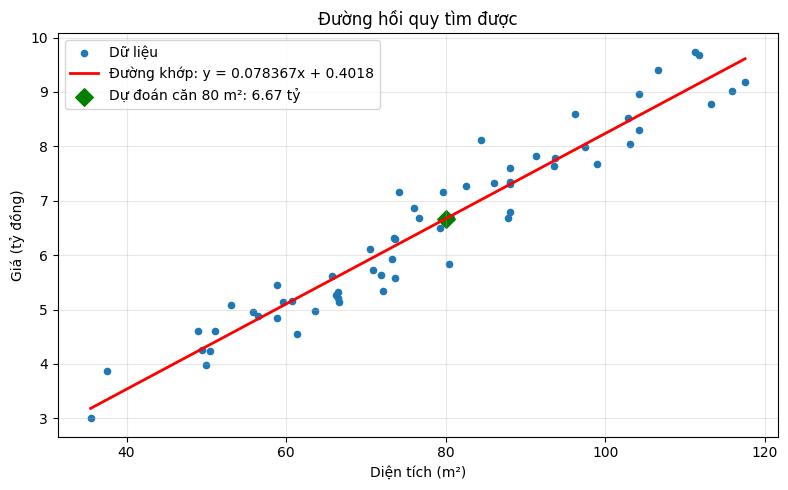

In [8]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/gia_nha.csv")

x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Hệ số hồi quy đã tính được
w = 0.078367
b = 0.4018

# Vẽ đường hồi quy
x_ve = np.linspace(x.min(), x.max(), 200)
y_ve = w * x_ve + b

plt.figure(figsize=(8, 5))

# Dữ liệu
plt.scatter(
    x,
    y,
    s=20,
    label="Dữ liệu"
)

# Đường hồi quy
plt.plot(
    x_ve,
    y_ve,
    color="red",
    linewidth=2,
    label=f"Đường khớp: y = {w:.6f}x + {b:.4f}"
)

# Dự đoán căn 80 m²
dien_tich_moi = 80
gia_du_doan = w * dien_tich_moi + b

plt.scatter(
    dien_tich_moi,
    gia_du_doan,
    color="green",
    marker="D",
    s=80,
    label=f"Dự đoán căn 80 m²: {gia_du_doan:.2f} tỷ"
)

plt.xlabel("Diện tích (m²)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Đường hồi quy tìm được")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

HÌNH 6

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


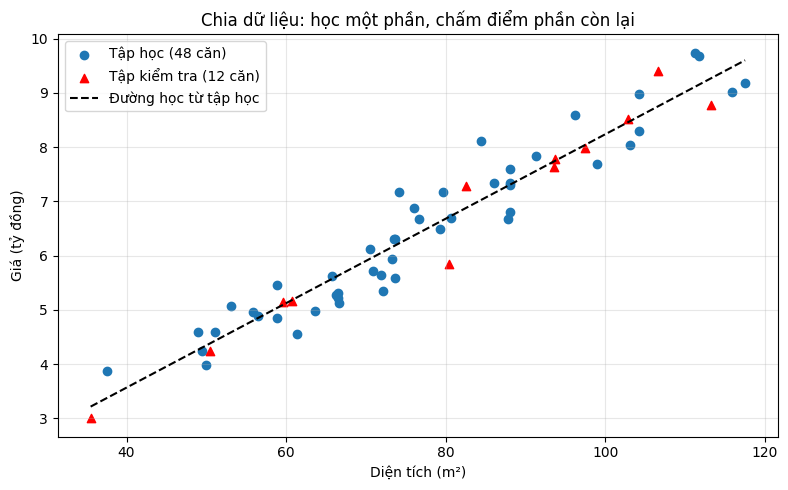

In [9]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/gia_nha.csv")

X = df[["dien_tich"]]
y = df["gia"]

# Chia dữ liệu: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Huấn luyện mô hình
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

# Tạo đường hồi quy
x_ve = np.linspace(
    df["dien_tich"].min(),
    df["dien_tich"].max(),
    200
).reshape(-1, 1)

y_ve = mo_hinh.predict(x_ve)

plt.figure(figsize=(8, 5))

# Tập học
plt.scatter(
    X_train["dien_tich"],
    y_train,
    label="Tập học (48 căn)"
)

# Tập kiểm tra
plt.scatter(
    X_test["dien_tich"],
    y_test,
    marker="^",
    color="red",
    label="Tập kiểm tra (12 căn)"
)

# Đường hồi quy
plt.plot(
    x_ve,
    y_ve,
    linestyle="--",
    color="black",
    label="Đường học từ tập học"
)

plt.xlabel("Diện tích (m²)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Chia dữ liệu: học một phần, chấm điểm phần còn lại")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

HÌNH 7

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


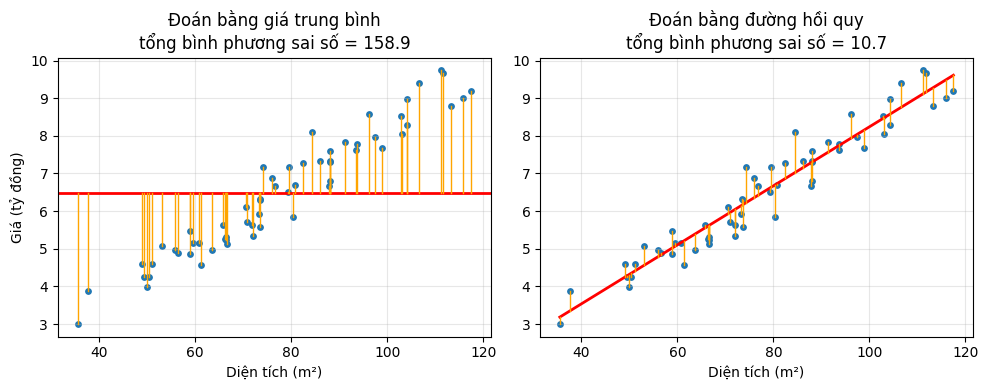

In [10]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

df = pd.read_csv("/content/gia_nha.csv")

x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# =========================
# Mô hình 1: dự đoán bằng giá trung bình
# =========================

gia_tb = y.mean()

# =========================
# Mô hình 2: hồi quy tuyến tính
# =========================

X = df[["dien_tich"]]

mo_hinh = LinearRegression()
mo_hinh.fit(X, y)

x_ve = np.linspace(x.min(), x.max(), 200)
y_hoi_quy = mo_hinh.predict(
    x_ve.reshape(-1, 1)
)

# =========================
# Vẽ hình
# =========================

fig, ax = plt.subplots(
    1, 2,
    figsize=(10, 4)
)

# -------------------------
# Bên trái: giá trung bình
# -------------------------

ax[0].scatter(
    x,
    y,
    s=15
)

ax[0].axhline(
    gia_tb,
    color="red",
    linewidth=2
)

for xi, yi in zip(x, y):
    ax[0].plot(
        [xi, xi],
        [yi, gia_tb],
        color="orange",
        linewidth=1
    )

ax[0].set_title(
    f"Đoán bằng giá trung bình\n"
    f"tổng bình phương sai số = "
    f"{((y - gia_tb) ** 2).sum():.1f}"
)

ax[0].set_xlabel("Diện tích (m²)")
ax[0].set_ylabel("Giá (tỷ đồng)")
ax[0].grid(True, alpha=0.3)

# -------------------------
# Bên phải: hồi quy tuyến tính
# -------------------------

ax[1].scatter(
    x,
    y,
    s=15
)

ax[1].plot(
    x_ve,
    y_hoi_quy,
    color="red",
    linewidth=2
)

y_du_doan = mo_hinh.predict(X)

for xi, yi, ypi in zip(x, y, y_du_doan):
    ax[1].plot(
        [xi, xi],
        [yi, ypi],
        color="orange",
        linewidth=1
    )

tong_binh_phuong_sai_so = (
    (y - y_du_doan) ** 2
).sum()

ax[1].set_title(
    f"Đoán bằng đường hồi quy\n"
    f"tổng bình phương sai số = "
    f"{tong_binh_phuong_sai_so:.1f}"
)

ax[1].set_xlabel("Diện tích (m²)")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

HÌNH 8

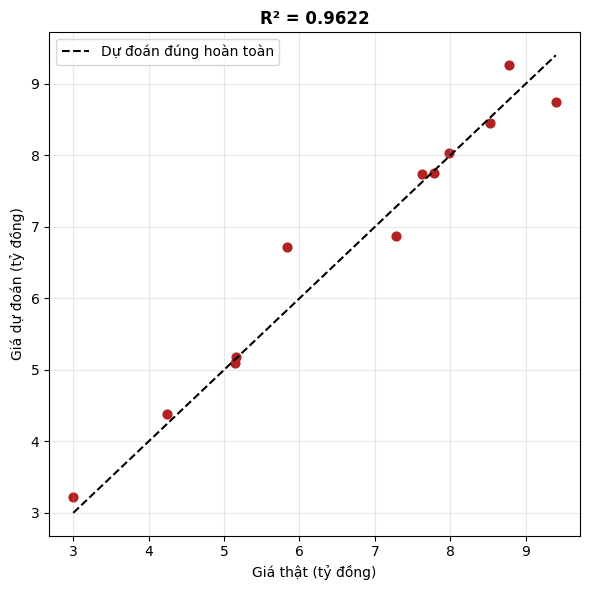

In [11]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

df = pd.read_csv("/content/gia_nha.csv")

X = df[["dien_tich"]]
y = df["gia"]

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Huấn luyện mô hình
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred = mo_hinh.predict(X_test)

# Tính R²
r2 = r2_score(y_test, y_pred)

# Vẽ biểu đồ
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    y_pred,
    color="firebrick",
    s=40
)

# Đường dự đoán hoàn toàn
gia_min = min(y_test.min(), y_pred.min())
gia_max = max(y_test.max(), y_pred.max())

plt.plot(
    [gia_min, gia_max],
    [gia_min, gia_max],
    linestyle="--",
    color="black",
    label="Dự đoán đúng hoàn toàn"
)

plt.xlabel("Giá thật (tỷ đồng)")
plt.ylabel("Giá dự đoán (tỷ đồng)")

plt.title(
    f"R² = {r2:.4f}",
    fontweight="bold"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

HÌNH 9

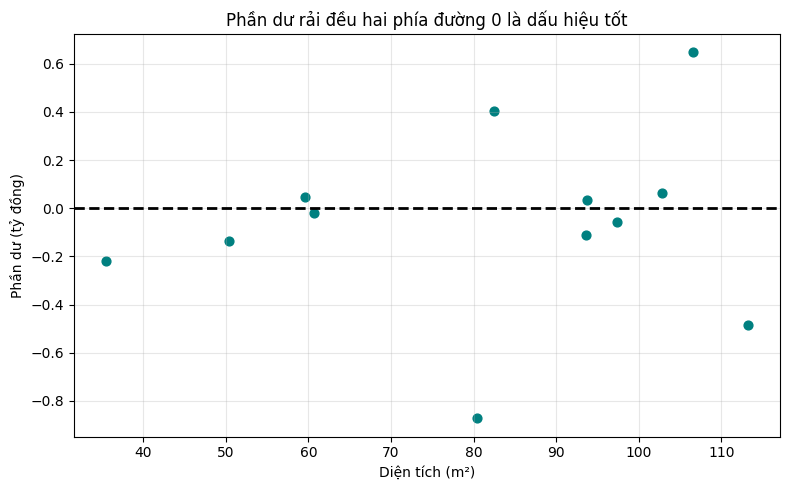

In [12]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/gia_nha.csv")

X = df[["dien_tich"]]
y = df["gia"]

# Chia dữ liệu 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Huấn luyện mô hình
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

# Dự đoán tập kiểm tra
y_pred = mo_hinh.predict(X_test)

# Phần dư = giá thật - giá dự đoán
phan_du = y_test.to_numpy() - y_pred

# Vẽ biểu đồ
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test["dien_tich"],
    phan_du,
    color="teal",
    s=40
)

# Đường phần dư bằng 0
plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Diện tích (m²)")
plt.ylabel("Phần dư (tỷ đồng)")
plt.title("Phần dư rải đều hai phía đường 0 là dấu hiệu tốt")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

HÌNH 10

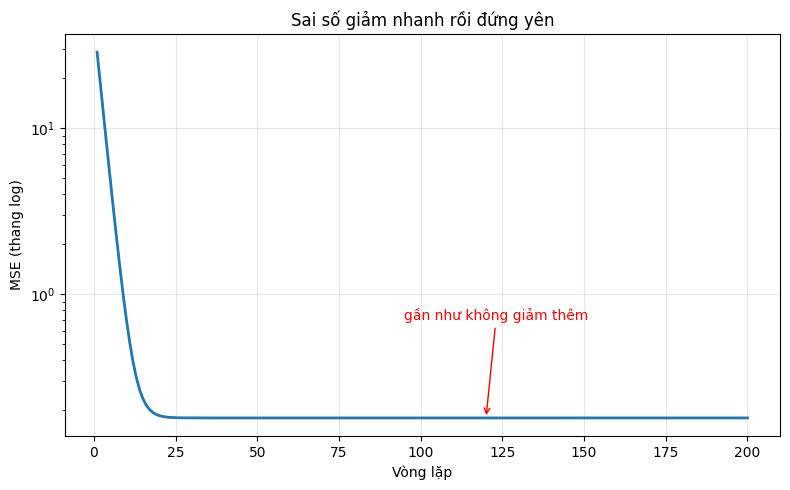

In [13]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/gia_nha.csv")

x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Chuẩn hóa x
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

# Khởi tạo
w = 0.0
b = 0.0

toc_do_hoc = 0.1
so_vong = 200
n = len(x)

mse_history = []

# Gradient Descent
for vong in range(1, so_vong + 1):

    y_du_doan = w * x + b

    chenh_lech = y_du_doan - y

    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()

    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

    # Tính MSE sau mỗi vòng
    mse = (((w * x + b) - y) ** 2).mean()

    mse_history.append(mse)

# =========================
# Vẽ biểu đồ
# =========================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, so_vong + 1),
    mse_history,
    linewidth=2
)

plt.yscale("log")

plt.xlabel("Vòng lặp")
plt.ylabel("MSE (thang log)")
plt.title("Sai số giảm nhanh rồi đứng yên")

# Chú thích
vi_tri = 120

plt.annotate(
    "gần như không giảm thêm",
    xy=(vi_tri, mse_history[vi_tri - 1]),
    xytext=(95, 0.7),
    color="red",
    arrowprops=dict(
        arrowstyle="->",
        color="red"
    )
)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

HÌNH 11

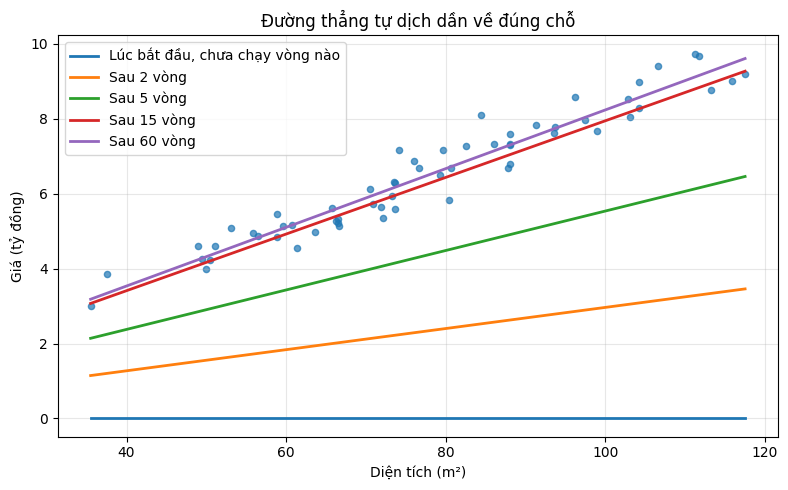

In [14]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/gia_nha.csv")

x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Chuẩn hóa diện tích
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

# Khởi tạo
w = 0.0
b = 0.0

toc_do_hoc = 0.1
so_vong = 60
n = len(x)

# Các vòng cần lưu để vẽ
cac_vong = [0, 2, 5, 15, 60]
ket_qua = {}

# Lưu đường ban đầu
ket_qua[0] = (w, b)

# Gradient Descent
for vong in range(1, so_vong + 1):

    y_du_doan = w * x + b
    chenh_lech = y_du_doan - y

    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()

    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

    if vong in cac_vong:
        ket_qua[vong] = (w, b)

# Đổi w, b về đơn vị diện tích m²
def doi_ve_thang_do(w_chuan, b_chuan):
    w_goc = w_chuan / x_do_lech
    b_goc = b_chuan - w_chuan * x_tb / x_do_lech
    return w_goc, b_goc

# Trục x để vẽ
x_ve = np.linspace(
    x_goc.min(),
    x_goc.max(),
    200
)

plt.figure(figsize=(8, 5))

# Dữ liệu
plt.scatter(
    x_goc,
    y,
    s=20,
    alpha=0.7
)

# Vẽ từng đường
for vong in cac_vong:

    w_temp, b_temp = ket_qua[vong]

    w_goc, b_goc = doi_ve_thang_do(
        w_temp,
        b_temp
    )

    y_ve = w_goc * x_ve + b_goc

    if vong == 0:
        nhan = "Lúc bắt đầu, chưa chạy vòng nào"
    else:
        nhan = f"Sau {vong} vòng"

    plt.plot(
        x_ve,
        y_ve,
        linewidth=2,
        label=nhan
    )

plt.xlabel("Diện tích (m²)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Đường thẳng tự dịch dần về đúng chỗ")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

HÌNH 12

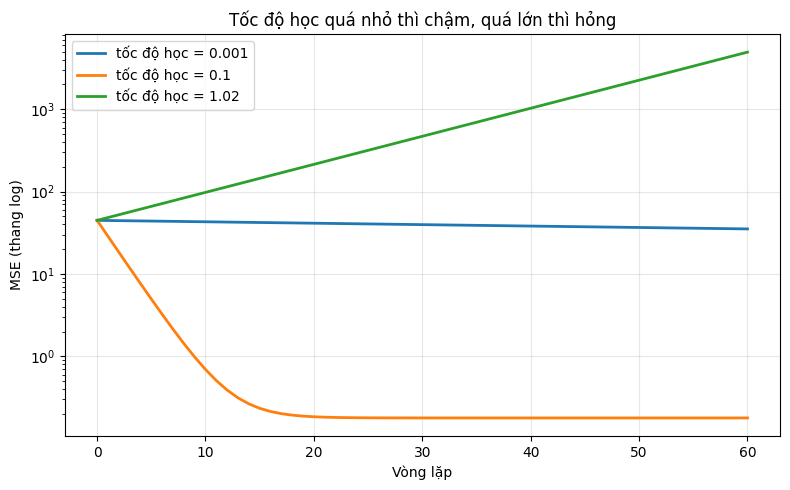

In [15]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/gia_nha.csv")

x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Chuẩn hóa x
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

n = len(x)

# 3 tốc độ học
cac_toc_do_hoc = [0.001, 0.1, 1.02]

so_vong = 60

plt.figure(figsize=(8, 5))

for toc_do_hoc in cac_toc_do_hoc:

    w = 0.0
    b = 0.0

    mse_history = []

    for vong in range(so_vong + 1):

        # Tính MSE hiện tại
        y_du_doan = w * x + b
        mse = ((y_du_doan - y) ** 2).mean()
        mse_history.append(mse)

        # Không cập nhật sau vòng cuối
        if vong == so_vong:
            break

        # Tính gradient
        chenh_lech = y_du_doan - y

        grad_w = (2 / n) * (chenh_lech * x).sum()
        grad_b = (2 / n) * chenh_lech.sum()

        # Cập nhật w và b
        w -= toc_do_hoc * grad_w
        b -= toc_do_hoc * grad_b

    plt.plot(
        range(so_vong + 1),
        mse_history,
        linewidth=2,
        label=f"tốc độ học = {toc_do_hoc}"
    )

# Trục MSE dạng log
plt.yscale("log")

plt.xlabel("Vòng lặp")
plt.ylabel("MSE (thang log)")
plt.title("Tốc độ học quá nhỏ thì chậm, quá lớn thì hỏng")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

HÌNH 13

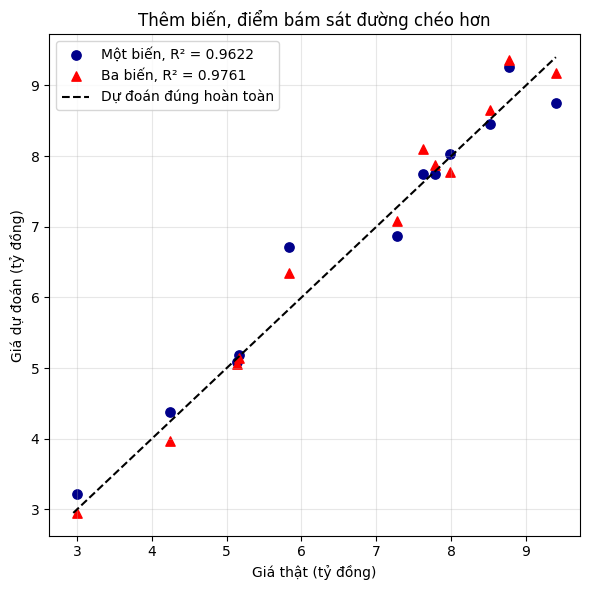

In [16]:
# -*- coding: utf-8 -*-

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

df = pd.read_csv("/content/gia_nha.csv")

y = df["gia"]

# Mô hình 1 biến
X_mot = df[["dien_tich"]]

# Mô hình 3 biến
X_ba = df[["dien_tich", "so_phong", "tuoi_nha"]]

# Chia dữ liệu giống nhau
X_train_1, X_test_1, y_train, y_test = train_test_split(
    X_mot,
    y,
    test_size=0.2,
    random_state=42
)

X_train_3, X_test_3, _, _ = train_test_split(
    X_ba,
    y,
    test_size=0.2,
    random_state=42
)

# Huấn luyện mô hình 1 biến
mo_hinh_1 = LinearRegression()
mo_hinh_1.fit(X_train_1, y_train)

y_pred_1 = mo_hinh_1.predict(X_test_1)
r2_1 = r2_score(y_test, y_pred_1)

# Huấn luyện mô hình 3 biến
mo_hinh_3 = LinearRegression()
mo_hinh_3.fit(X_train_3, y_train)

y_pred_3 = mo_hinh_3.predict(X_test_3)
r2_3 = r2_score(y_test, y_pred_3)

# =========================
# Vẽ biểu đồ
# =========================

plt.figure(figsize=(6, 6))

# Mô hình 1 biến
plt.scatter(
    y_test,
    y_pred_1,
    color="darkblue",
    s=45,
    label=f"Một biến, R² = {r2_1:.4f}"
)

# Mô hình 3 biến
plt.scatter(
    y_test,
    y_pred_3,
    color="red",
    marker="^",
    s=45,
    label=f"Ba biến, R² = {r2_3:.4f}"
)

# Đường dự đoán hoàn toàn chính xác
gia_min = min(
    y_test.min(),
    y_pred_1.min(),
    y_pred_3.min()
)

gia_max = max(
    y_test.max(),
    y_pred_1.max(),
    y_pred_3.max()
)

plt.plot(
    [gia_min, gia_max],
    [gia_min, gia_max],
    linestyle="--",
    color="black",
    label="Dự đoán đúng hoàn toàn"
)

plt.xlabel("Giá thật (tỷ đồng)")
plt.ylabel("Giá dự đoán (tỷ đồng)")

plt.title("Thêm biến, điểm bám sát đường chéo hơn")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

HÌNH 14

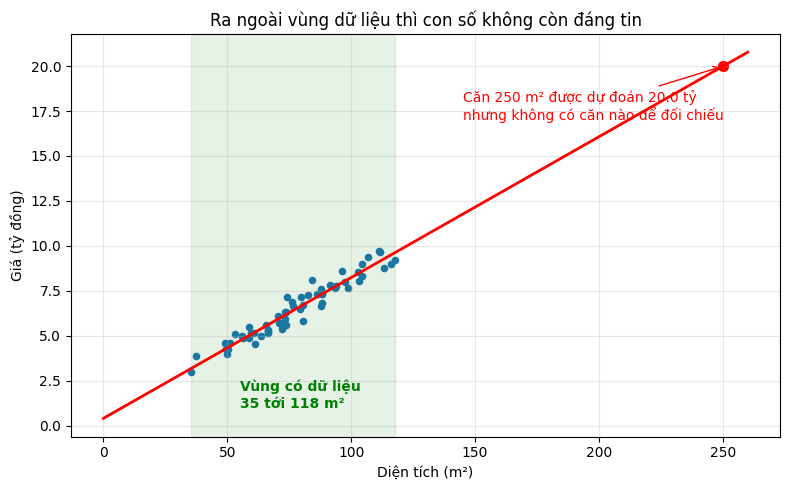

In [17]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/gia_nha.csv")

x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Hệ số hồi quy
w = 0.078367
b = 0.401752

# Tạo đường hồi quy kéo dài đến 260 m²
x_ve = np.linspace(0, 260, 300)
y_ve = w * x_ve + b

plt.figure(figsize=(8, 5))

# Dữ liệu thật
plt.scatter(
    x,
    y,
    s=20,
    label="Dữ liệu"
)

# Vùng dữ liệu thực tế
plt.axvspan(
    35.5,
    117.5,
    color="green",
    alpha=0.1
)

# Đường hồi quy
plt.plot(
    x_ve,
    y_ve,
    color="red",
    linewidth=2
)

# Dự đoán 250 m²
dien_tich = 250
gia_du_doan = w * dien_tich + b

plt.scatter(
    dien_tich,
    gia_du_doan,
    color="red",
    s=50
)

# Chú thích vùng dữ liệu
plt.text(
    55,
    1.0,
    "Vùng có dữ liệu\n35 tới 118 m²",
    color="green",
    fontweight="bold"
)

# Chú thích dự đoán 250 m²
plt.annotate(
    f"Căn 250 m² được dự đoán {gia_du_doan:.1f} tỷ\n"
    "nhưng không có căn nào để đối chiếu",
    xy=(250, gia_du_doan),
    xytext=(145, 17),
    color="red",
    arrowprops=dict(
        arrowstyle="->",
        color="red"
    )
)

plt.xlabel("Diện tích (m²)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Ra ngoài vùng dữ liệu thì con số không còn đáng tin")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()